In [1]:
!pip install -q scikit-learn matplotlib seaborn

In [4]:
import os
import shutil
from google.colab import drive

# 1. Ensure Drive is mounted
drive.mount('/content/drive')

# 2. Define exact source and destination
SOURCE = '/content/drive/MyDrive/satellite_image/model_dataset/EuroSat/test'
DEST = '/content/EuroSat_Local/test'

print(f"\nChecking for source directory:\n{SOURCE}")

# 3. Safe Copy Logic
if not os.path.exists(SOURCE):
    print("\n❌ ERROR: Colab cannot see this folder on your Drive.")
    print("Please double check your Google Drive to ensure the 'test' folder is inside 'EuroSat'.")
    print("Also check for spaces in your folder names (e.g., 'satellite image' vs 'satellite_image').")
else:
    print("✓ Source found! Copying files to local fast storage...")

    # If a partial folder exists from a failed attempt, clear it out first
    if os.path.exists(DEST):
        shutil.rmtree(DEST)

    # Copy everything over
    shutil.copytree(SOURCE, DEST)

    # Verify the count
    total_files = sum(len(files) for r, d, files in os.walk(DEST))
    print(f"✅ Success! Total test images securely copied to local storage: {total_files}")

Mounted at /content/drive

Checking for source directory:
/content/drive/MyDrive/satellite_image/model_dataset/EuroSat/test
✓ Source found! Copying files to local fast storage...
✅ Success! Total test images securely copied to local storage: 4050


Using device: cuda
Loading test data from /content/EuroSat_Local/test...
Found 4050 images across 10 classes.
Loading model weights from /content/drive/MyDrive/satellite_image/EuroSAT_Models/dinov2_eurosat_best.pth...
Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip


/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vitb14/dinov2_vitb14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vitb14_pretrain.pth


100%|██████████| 330M/330M [00:00<00:00, 448MB/s]


Running inference on test dataset...

CLASSIFICATION REPORT
                      precision    recall  f1-score   support

          AnnualCrop     0.9558    0.9133    0.9341       450
              Forest     0.9795    0.9533    0.9662       450
HerbaceousVegetation     0.9567    0.9333    0.9449       450
             Highway     0.8979    0.9147    0.9062       375
          Industrial     0.9320    0.9867    0.9585       375
             Pasture     0.8861    0.9333    0.9091       300
       PermanentCrop     0.8773    0.8960    0.8865       375
         Residential     0.9582    0.9689    0.9635       450
               River     0.9403    0.8827    0.9106       375
             SeaLake     0.9651    0.9822    0.9736       450

            accuracy                         0.9378      4050
           macro avg     0.9349    0.9364    0.9353      4050
        weighted avg     0.9384    0.9378    0.9378      4050


Generating Confusion Matrix Plot...


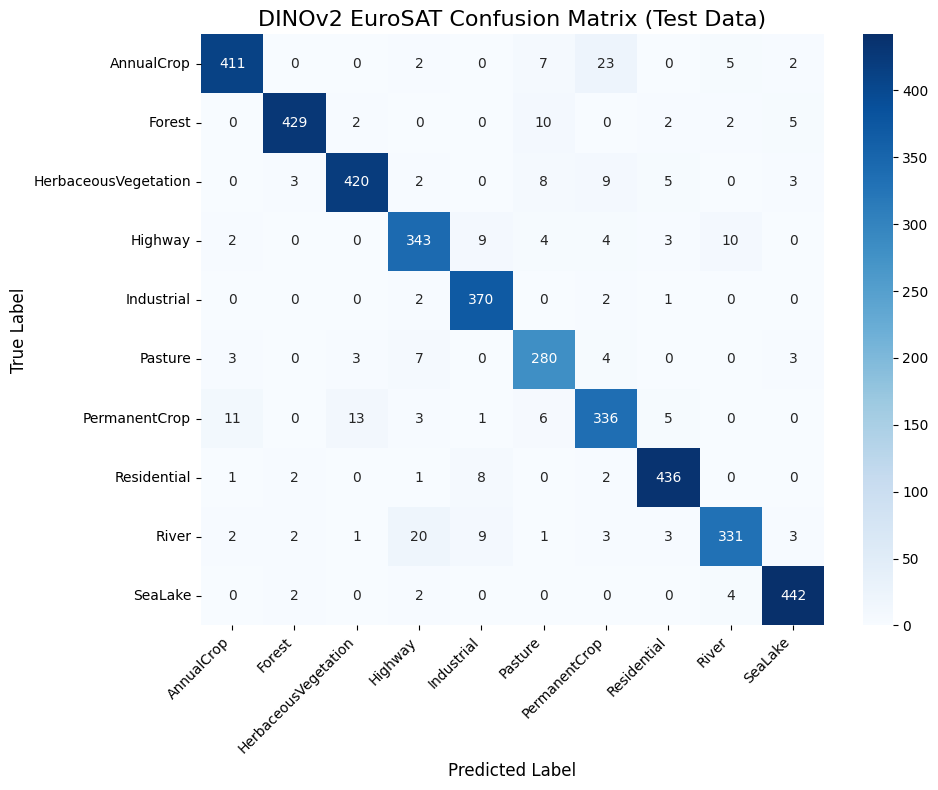

In [5]:
import os
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix

# =====================================================================
# 1. CONFIGURATION
# =====================================================================
# Point this to your saved best model on Google Drive
BEST_MODEL_PATH = '/content/drive/MyDrive/satellite_image/EuroSAT_Models/dinov2_eurosat_best.pth'

# Point this to the test folder in your lightning-fast local storage
TEST_DIR = '/content/EuroSat_Local/test'

BATCH_SIZE = 256
NUM_CLASSES = 10
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# =====================================================================
# 2. DATA LOADING
# =====================================================================
if not os.path.exists(TEST_DIR):
    raise FileNotFoundError(f"Could not find {TEST_DIR}. Did the copy command finish successfully?")

test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print(f"Loading test data from {TEST_DIR}...")
test_dataset = datasets.ImageFolder(root=TEST_DIR, transform=test_transforms)

# num_workers=2 is safe here because we are reading from local NVMe storage, not Drive
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

CLASSES = test_dataset.classes
print(f"Found {len(test_dataset)} images across {len(CLASSES)} classes.")

# =====================================================================
# 3. REBUILD ARCHITECTURE & LOAD WEIGHTS
# =====================================================================
class DINOv2LinearProbe(nn.Module):
    def __init__(self, model_name='dinov2_vitb14', num_classes=10):
        super().__init__()
        self.backbone = torch.hub.load('facebookresearch/dinov2', model_name)
        for param in self.backbone.parameters():
            param.requires_grad = False

        embed_dim = self.backbone.embed_dim
        self.classifier = nn.Sequential(
            nn.BatchNorm1d(embed_dim),
            nn.Dropout(0.2),
            nn.Linear(embed_dim, num_classes)
        )

    def forward(self, x):
        with torch.no_grad():
            features = self.backbone(x)
        return self.classifier(features)

print(f"Loading model weights from {BEST_MODEL_PATH}...")
model = DINOv2LinearProbe().to(DEVICE)
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))
model.eval()

# =====================================================================
# 4. RUN EVALUATION LOOP
# =====================================================================
all_preds = []
all_labels = []

print("Running inference on test dataset...")
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)

        # Using modern AMP syntax for faster inference
        with torch.amp.autocast('cuda'):
            outputs = model(images)

        _, preds = torch.max(outputs, 1)

        # Move back to CPU for sklearn metrics
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# =====================================================================
# 5. GENERATE METRICS & PLOTS
# =====================================================================
print("\n" + "="*50)
print("CLASSIFICATION REPORT")
print("="*50)
print(classification_report(all_labels, all_preds, target_names=CLASSES, digits=4))

print("\nGenerating Confusion Matrix Plot...")
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.title('DINOv2 EuroSAT Confusion Matrix (Test Data)', fontsize=16)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()